In [131]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import vector
import matplotlib

In [132]:
file = uproot.open("sample_root_files/output_570.root")

In [133]:
events_tree = file['Events']

In [134]:
jet_pt = events_tree['Jet_pt'].array()
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [135]:
jet_pt_above_500 = jet_pt > 500
eft_coeff_above_500 = []
eft_coeff_below_500 = []

for i in range(len(jet_pt_above_500)):
    if True in jet_pt_above_500[i]:
        eft_coeff_above_500.append(np.argmax(abs(eft_coeff[i])))
    else:
        eft_coeff_below_500.append(np.argmax(abs(eft_coeff[i])))

In [136]:
def weights(data):
    return [1 / len(data)] * len(data)

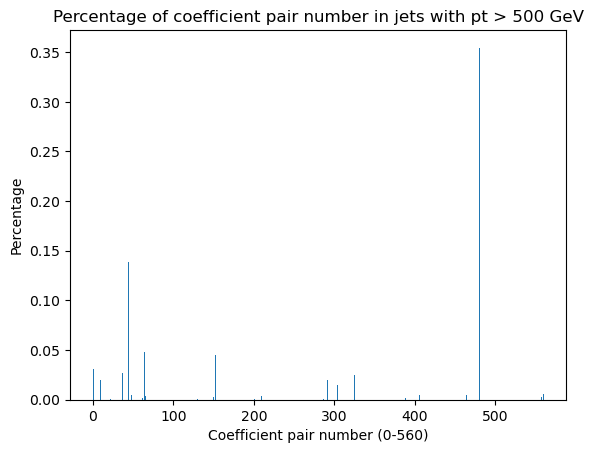

In [148]:
plt.hist(eft_coeff_above_500, bins = 560, weights = weights(eft_coeff_above_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with pt > 500 GeV')
plt.show()

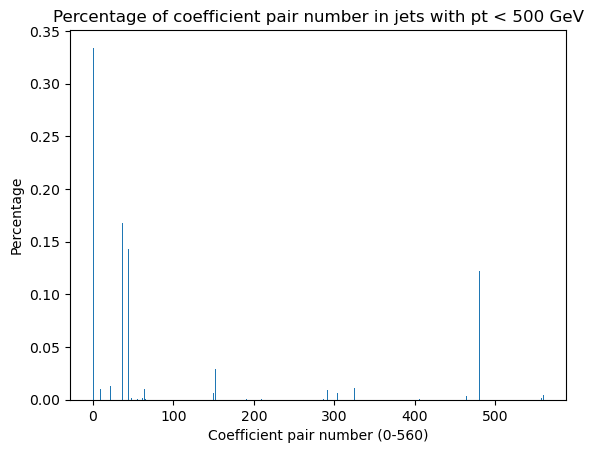

In [146]:
plt.hist(eft_coeff_below_500, bins=560, weights = weights(eft_coeff_below_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with pt < 500 GeV')
plt.show()

In [157]:
a = 0
for i in eft_coeff_below_500:
    if i == 0:
        a += 1
print(a/len(eft_coeff_below_500))

0.3342121476981273
